In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [2]:
df=pd.read_csv('./covid_cases.csv')

In [3]:
df['Date']=pd.to_datetime(df['Date'])

In [4]:
df['Days']=(
    df['Date']-df['Date'].min()
).dt.days

In [5]:
X=df[['Days']]
y=df['Cases']


In [8]:
for i in range(1,6):
    poly=PolynomialFeatures(degree=i)
    x_poly=poly.fit_transform(X)
    model=LinearRegression()
    model.fit(x_poly,y)
    y_pred=model.predict(x_poly)
    print(f'{i}: {metrics.r2_score(y,y_pred)}')

1: 0.9995759497602076
2: 0.999576030325016
3: 0.9995835444931465
4: 0.999603324356539
5: 0.9988995418875906


In [10]:
poly=PolynomialFeatures(degree=4)
x_poly=poly.fit_transform(X)


In [12]:
X_train,X_test,y_train,y_test=train_test_split(
    x_poly,y,test_size=0.2,random_state=42
)

In [13]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f'R2 score: {metrics.r2_score(y_pred,y_test)}')

R2 score: 0.9994974484639718


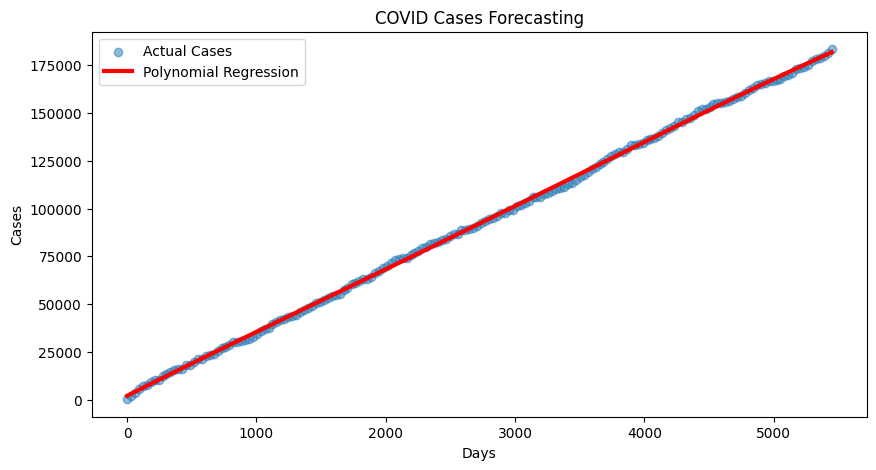

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    X,
    y,
    alpha=0.5,
    label='Actual Cases'
)

plt.plot(
    X,
    model.predict(x_poly),
    color='red',
    linewidth=3,
    label='Polynomial Regression'
)

plt.xlabel('Days')

plt.ylabel('Cases')

plt.title('COVID Cases Forecasting')

plt.legend()

plt.show()